Start - načtení dat a knihoven 

In [28]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", None)   

In [29]:
URL = "https://raw.githubusercontent.com/owid/co2-data/master/owid-co2-data.csv"
df = pd.read_csv(URL)            
print("Rozměr datasetu:", df.shape)

Rozměr datasetu: (50411, 79)


In [30]:
# ověření sloupců
chci = ["country", "year", "iso_code", "co2", "population", "gdp", "primary_energy_consumption"]
print("sloupce:", [c for c in chci if c in df.columns])
df[chci].head()

sloupce: ['country', 'year', 'iso_code', 'co2', 'population', 'gdp', 'primary_energy_consumption']


,country,year,iso_code,co2,population,gdp,primary_energy_consumption
0,Afghanistan,1750,AFG,NaN,2802560.0,NaN,NaN
1,Afghanistan,1751,AFG,NaN,NaN,NaN,NaN
2,Afghanistan,1752,AFG,NaN,NaN,NaN,NaN
3,Afghanistan,1753,AFG,NaN,NaN,NaN,NaN
4,Afghanistan,1754,AFG,NaN,NaN,NaN,NaN


In [31]:
# rok
usa_raw = df[(df["country"] == "United States") & df["year"].between(1990, 2024)]
for c in ["co2", "population", "gdp", "primary_energy_consumption"]:
    print(f"{c:28s} poslední rok s daty:", int(usa_raw.loc[usa_raw[c].notna(), "year"].max()))

co2                          poslední rok s daty: 2024
population                   poslední rok s daty: 2024
gdp                          poslední rok s daty: 2022
primary_energy_consumption   poslední rok s daty: 2024


`spocti_kaya(zeme)` - fce, na výpočet

In [32]:
## data z WB
def _hdp_worldbank(iso, rok_od, rok_do):
    try:
        from pandas_datareader import wb
        g = wb.download(indicator="NY.GDP.MKTP.KD", country=iso,
                        start=rok_od, end=rok_do).reset_index()
        g = g.rename(columns={"NY.GDP.MKTP.KD": "gdp_wb"})
        g["year"] = g["year"].astype(int)
        return g[["year", "gdp_wb"]]
    except Exception as e:
        print(f"  ! World Bank HDP pro {iso} nedostupné ({type(e).__name__}); použiju HDP z OWID")
        return None

In [33]:
def spocti_kaya(zeme, rok_od=1990, rok_do=2024, gdp_zdroj="worldbank"):
    d = df[(df["country"] == zeme) & (df["year"].between(rok_od, rok_do))].copy()
    d = d.sort_values("year").reset_index(drop=True)
    if d.empty:
        print(f"  ! '{zeme}' není v datasetu")
        return None

    if gdp_zdroj == "worldbank":
        iso = d["iso_code"].dropna().iloc[0]
        g = _hdp_worldbank(iso, rok_od, rok_do)
        if g is not None:
            d = d.merge(g, on="year", how="left")
            d["gdp"] = d["gdp_wb"]

 
    d["gdp_pc"]  = d["gdp"] / d["population"]                     
    d["en_int"]  = d["primary_energy_consumption"] / d["gdp"]     
    d["co2_int"] = d["co2"] / d["primary_energy_consumption"]     

    for c in ["population", "gdp_pc", "en_int", "co2_int", "co2"]:
        d[c + "_g"] = d[c].pct_change() * 100 ##%/rok

    prispevky = ["population_g", "gdp_pc_g", "en_int_g", "co2_int_g"]
    soucet = d[prispevky].sum(axis=1, min_count=len(prispevky))
    d["interactions"] = d["co2_g"] - soucet
    return d

In [34]:
slozky = [
    ("population_g", "Population",     "#9ec94a"),  
    ("gdp_pc_g",     "GDP/Population", "#e0529c"),  
    ("en_int_g",     "Energy/GDP",     "#5fc2a0"),  
    ("co2_int_g",    "CO2/Energy",     "#7ea8c9"),  
    ("interactions", "Interactions",   "#9a9a9a"), 
]

def vykresli_kaya(d, zeme, ax=None):
    need = ["co2_g", "population_g", "gdp_pc_g", "en_int_g", "co2_int_g", "interactions"]
    g = d.dropna(subset=need).copy()       
    roky = g["year"].values
    n = len(roky)

    if ax is None:
        _, ax = plt.subplots(figsize=(11, 6))

    dno_plus  = np.zeros(n)
    dno_minus = np.zeros(n)
    for sloupec, popisek, barva in slozky:
        v = g[sloupec].values
        kladne  = np.where(v > 0, v, 0)       
        zaporne = np.where(v < 0, v, 0)       
        ax.bar(roky, kladne,  bottom=dno_plus,  color=barva, width=0.8, label=popisek)
        ax.bar(roky, zaporne, bottom=dno_minus, color=barva, width=0.8)
        dno_plus  += kladne
        dno_minus += zaporne

    ax.scatter(roky, g["co2_g"], color="black", s=18, zorder=5, label="Fossil CO2")
    ax.axhline(0, color="black", linewidth=0.8)
    ax.set_title(zeme)
    ax.grid(axis="y", alpha=0.3)
    return ax

Graf - pouze USA

sedí: True


/var/folders/92/l0f05y190kgfkq8s58v1j9040000gn/T/ipykernel_79250/2566174691.py:5: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_numeric without passing `errors` and catch exceptions explicitly instead
  g = wb.download(indicator="NY.GDP.MKTP.KD", country=iso,


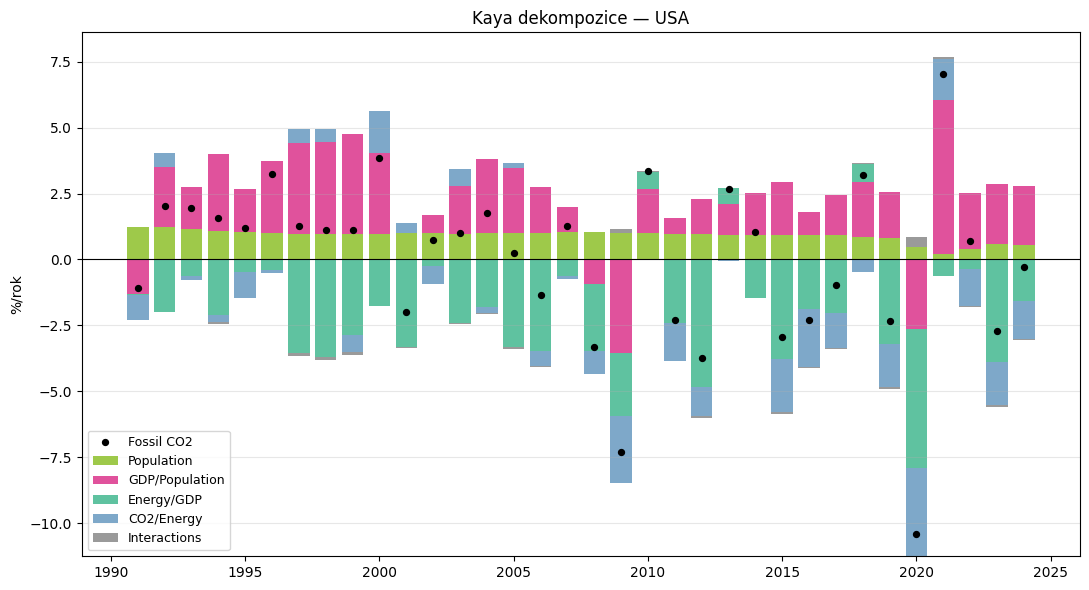

In [35]:
d_usa = spocti_kaya("United States")

rek = d_usa["population"] * d_usa["gdp_pc"] * d_usa["en_int"] * d_usa["co2_int"]
mask = rek.notna() & d_usa["co2"].notna()
print("sedí:", np.allclose(rek[mask], d_usa["co2"][mask]))

vykresli_kaya(d_usa, "United States")
plt.title("Kaya dekompozice — USA")
plt.ylabel("%/rok")
plt.legend(loc="lower left", fontsize=9)
plt.tight_layout()
plt.show()

Srovnávání zemí 

In [36]:
zeme_set = [
    "United States",   # základ
    "China",           # prudký nárůst, emise 
    "India",           # rychle rostoucí, emise stále nahoru
    "Germany",         # cílená dekarbonizace (pokus)
    "Poland",          # uhlí
    "Czechia",         
    "United Kingdom",  # konec uhlí
    "Russia",          # významný export fosilních paliv
]

In [37]:
vysledky = {}
for zeme in zeme_set:
    print("Počítám:", zeme)
    d = spocti_kaya(zeme)
    if d is not None:
        vysledky[zeme] = d
print("\nSpočítáno zemí:", len(vysledky))

Počítám: United States
Počítám: China


/var/folders/92/l0f05y190kgfkq8s58v1j9040000gn/T/ipykernel_79250/2566174691.py:5: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_numeric without passing `errors` and catch exceptions explicitly instead
  g = wb.download(indicator="NY.GDP.MKTP.KD", country=iso,
/var/folders/92/l0f05y190kgfkq8s58v1j9040000gn/T/ipykernel_79250/2566174691.py:5: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_numeric without passing `errors` and catch exceptions explicitly instead
  g = wb.download(indicator="NY.GDP.MKTP.KD", country=iso,


Počítám: India


/var/folders/92/l0f05y190kgfkq8s58v1j9040000gn/T/ipykernel_79250/2566174691.py:5: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_numeric without passing `errors` and catch exceptions explicitly instead
  g = wb.download(indicator="NY.GDP.MKTP.KD", country=iso,


Počítám: Germany


...

/var/folders/92/l0f05y190kgfkq8s58v1j9040000gn/T/ipykernel_79250/2566174691.py:5: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_numeric without passing `errors` and catch exceptions explicitly instead
  g = wb.download(indicator="NY.GDP.MKTP.KD", country=iso,


Počítám: United Kingdom


/var/folders/92/l0f05y190kgfkq8s58v1j9040000gn/T/ipykernel_79250/2566174691.py:5: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_numeric without passing `errors` and catch exceptions explicitly instead
  g = wb.download(indicator="NY.GDP.MKTP.KD", country=iso,


Počítám: Russia

Spočítáno zemí: 8


/var/folders/92/l0f05y190kgfkq8s58v1j9040000gn/T/ipykernel_79250/2566174691.py:5: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_numeric without passing `errors` and catch exceptions explicitly instead
  g = wb.download(indicator="NY.GDP.MKTP.KD", country=iso,


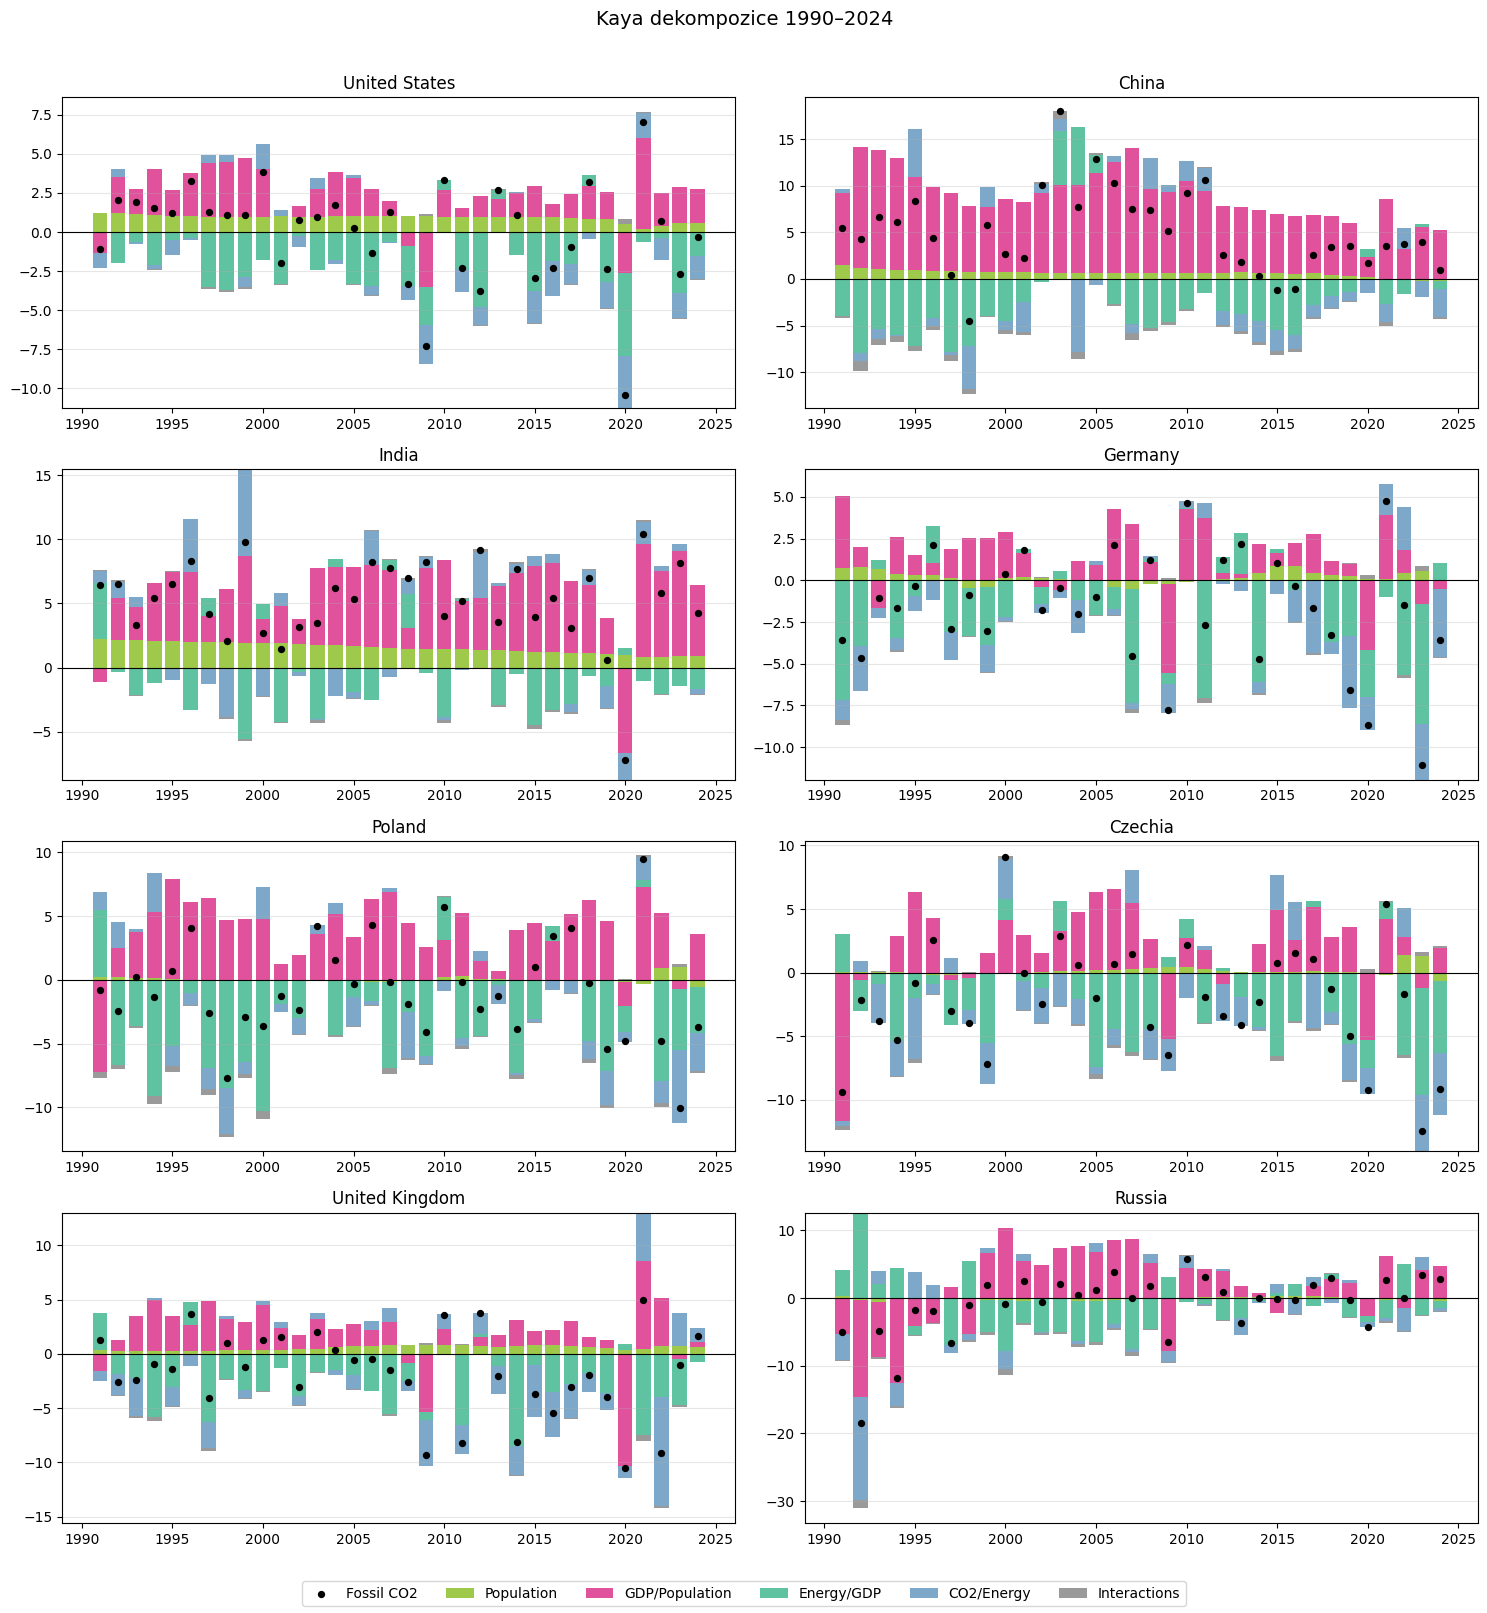

In [38]:
zeme_k = list(vysledky.keys())
n = len(zeme_k)
sloupcu = 2
radku = int(np.ceil(n / sloupcu))

fig_zeme, axes = plt.subplots(radku, sloupcu, figsize=(15, 4 * radku))
axes = np.array(axes).flatten()                

for i, zeme in enumerate(zeme_k):
    vykresli_kaya(vysledky[zeme], zeme, ax=axes[i])
for j in range(n, len(axes)):                  
    axes[j].set_visible(False)

pops, popisky = axes[0].get_legend_handles_labels()
fig_zeme.legend(pops, popisky, loc="lower center", ncol=6, fontsize=10)
fig_zeme.suptitle("Kaya dekompozice 1990–2024", fontsize=14, y=1.0)
fig_zeme.tight_layout(rect=[0, 0.03, 1, 0.99])
fig_zeme.savefig("kaya_zeme.png", dpi=150, bbox_inches="tight")   # matplotlib figura -> savefig
plt.show()

MAPOVÁ SEKCE

Každá mapa ukazuje jiný rozměr.
Ošetřeno pro stahování plotly 
Spíše jde o pokus

In [1]:
import importlib, subprocess, sys
if importlib.util.find_spec("plotly") is None:
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", "plotly"])
import plotly.express as px
print("plotly připraveno")

plotly připraveno


Změna uhlíkové intenzity energie 

In [40]:
rok_zac, rok_kon = 1990, 2023
m = df[df["year"].isin([rok_zac, rok_kon])].copy()
m["co2_int"] = m["co2"] / m["primary_energy_consumption"]
m = m[m["iso_code"].notna() & (m["iso_code"].str.len() == 3)]    # vyřaď agregáty (World, Europe…)

piv = m.pivot_table(index=["country", "iso_code"], columns="year", values="co2_int").dropna()
piv["zmena_pct"] = (piv[rok_kon] / piv[rok_zac] - 1) * 100
piv = piv.reset_index()
print("Zemí na mapě:", len(piv))

fig_mapa1 = px.choropleth(
    piv, locations="iso_code", color="zmena_pct", hover_name="country",
    color_continuous_scale="RdBu_r", range_color=(-60, 60),
    labels={"zmena_pct": "Změna CO₂/E (%)"},
    title=f"Změna uhlíkové intenzity energie {rok_zac}–{rok_kon}",
)
fig_mapa1.update_layout(margin=dict(l=0, r=0, t=40, b=0))
fig_mapa1.write_html("mapa_uhlikatost.html")   # PNG: ikona fotoaparátu v grafu, nebo write_image (+kaleido)
fig_mapa1.show()

Zemí na mapě: 191


Absolutní emise (proporční symboly)

In [41]:
rok = 2023
sym = df[(df["year"] == rok) & df["iso_code"].notna()
         & (df["iso_code"].str.len() == 3)].copy()
sym = sym.dropna(subset=["co2"])
sym = sym[sym["co2"] > 0]

fig_mapa2 = px.scatter_geo(
    sym, locations="iso_code", size="co2", color="co2", hover_name="country",
    size_max=55, color_continuous_scale="YlOrRd", projection="natural earth",
    title=f"Absolutní fosilní emise CO₂ ({rok})",
)
fig_mapa2.update_layout(margin=dict(l=0, r=0, t=40, b=0))
fig_mapa2.show()

bohatství × uhlík

In [42]:
rok = 2022  
b = df[(df["year"] == rok) & df["iso_code"].notna()
       & (df["iso_code"].str.len() == 3)].copy()
b["co2_int"] = b["co2"] / b["primary_energy_consumption"]
b["gdp_pc"]  = b["gdp"] / b["population"]
b = b.dropna(subset=["gdp_pc", "co2_int"])

print("Zemí s platnými daty:", len(b))
assert len(b) >= 9, "Příliš málo zemí (HDP neodstupno)"

b["tA"] = pd.qcut(b["gdp_pc"],  3, labels=[0, 1, 2]).astype(int)   
b["tB"] = pd.qcut(b["co2_int"], 3, labels=[0, 1, 2]).astype(int)  
b["trida"] = 3 * b["tB"] + b["tA"]

palette = ['#e8e8e8', '#ace4e4', '#5ac8c8',
           '#dfb0d6', '#a5add3', '#5698b9',
           '#be64ac', '#8c62aa', '#3b4994']
popisky = ["HDP nízké · mix čistý",  "HDP stř · mix čistý",   "HDP vys · mix čistý",
           "HDP nízké · mix stř",    "HDP stř · mix stř",     "HDP vys · mix stř",
           "HDP nízké · mix uhlík.", "HDP stř · mix uhlík.",  "HDP vys · mix uhlík."]
b["kategorie"] = b["trida"].map(dict(enumerate(popisky)))

fig_mapa3 = px.choropleth(
    b, locations="iso_code", color="kategorie", hover_name="country",
    category_orders={"kategorie": popisky},
    color_discrete_map={popisky[i]: palette[i] for i in range(9)},
    title=f" bohatství × uhlík ({rok})",
)
fig_mapa3.update_layout(margin=dict(l=0, r=0, t=40, b=0))
fig_mapa3.show()

Zemí s platnými daty: 164


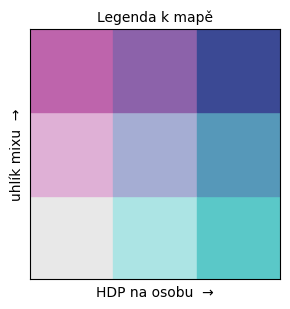

In [43]:

grid = np.array(palette).reshape(3, 3)
fig_leg, ax = plt.subplots(figsize=(3.2, 3.2))
for r in range(3):
    for c in range(3):
        ax.add_patch(plt.Rectangle((c, r), 1, 1, color=grid[r, c]))
ax.set_xlim(0, 3); ax.set_ylim(0, 3); ax.set_xticks([]); ax.set_yticks([])
ax.set_xlabel("HDP na osobu  →", fontsize=10)
ax.set_ylabel("uhlík mixu  →", fontsize=10)
ax.set_title("Legenda k mapě", fontsize=10)
ax.set_aspect("equal")
fig_leg.tight_layout()
fig_leg.savefig("legenda.png", dpi=150, bbox_inches="tight")
plt.show()

offshoring

In [44]:
rok = 2022
t = df[(df["year"] == rok) & df["iso_code"].notna()
       & (df["iso_code"].str.len() == 3)].copy()
if "trade_co2" in t.columns:
    t = t.dropna(subset=["trade_co2"])
    fig_mapa4 = px.choropleth(
        t, locations="iso_code", color="trade_co2", hover_name="country",
        color_continuous_scale="RdBu_r", range_color=(-300, 300),
        labels={"trade_co2": "Čistý obchod CO₂ (Mt)"},  
        title=f"Vývoz a dovoz zabudovaných emisí CO₂ ({rok})",
    )
    fig_mapa4.update_layout(margin=dict(l=0, r=0, t=40, b=0))
    fig_mapa4.show()
else:
    print("Sloupec trade_co2 v datasetu není.")

Pokusy



Kumulativní rozklad (čistý dlouhodobý efekt každého faktoru)

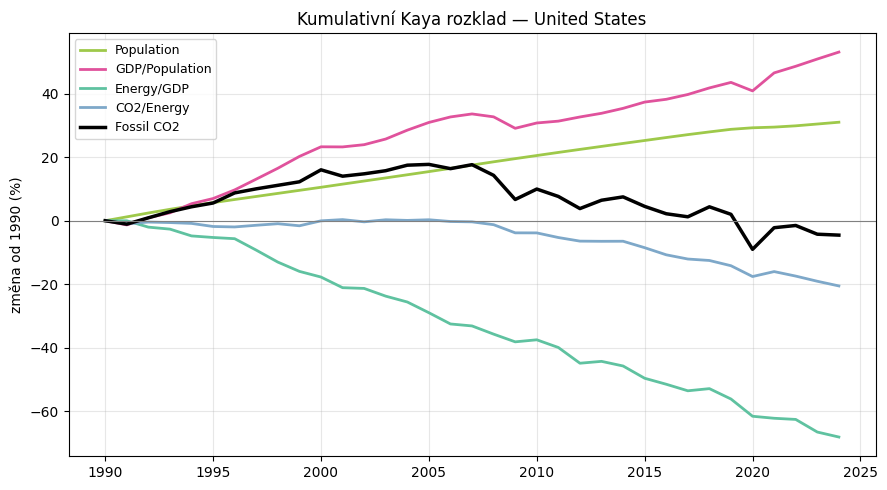

In [45]:
def vykresli_kaya_kumulativ(d, zeme, ax=None):
    """O kolik % každý faktor posunul emise od prvního roku (kumulativně, log)."""
    g = d.dropna(subset=["population", "gdp_pc", "en_int", "co2_int", "co2"]).copy()
    base = g.iloc[0]
    if ax is None:
        _, ax = plt.subplots(figsize=(9, 5))
    for col, popisek, barva in [("population", "Population",     "#9ec94a"),
                                ("gdp_pc",     "GDP/Population", "#e0529c"),
                                ("en_int",     "Energy/GDP",     "#5fc2a0"),
                                ("co2_int",    "CO2/Energy",     "#7ea8c9")]:
        ax.plot(g["year"], 100 * np.log(g[col] / base[col]), label=popisek, color=barva, lw=2)
    # černá = skutečná kumulativní změna emisí; rovná se přesně součtu čtyř křivek
    ax.plot(g["year"], 100 * np.log(g["co2"] / base["co2"]),
            label="Fossil CO2", color="black", lw=2.5)
    ax.axhline(0, color="gray", lw=0.8)
    ax.set_title(f"Kumulativní Kaya rozklad — {zeme}")
    ax.set_ylabel(f"změna od {int(base['year'])} (%)")
    ax.legend(fontsize=9)
    ax.grid(alpha=0.3)
    return ax

vykresli_kaya_kumulativ(d_usa, "United States")
plt.tight_layout()
plt.show()

Decoupling: indexovaný vývoj 

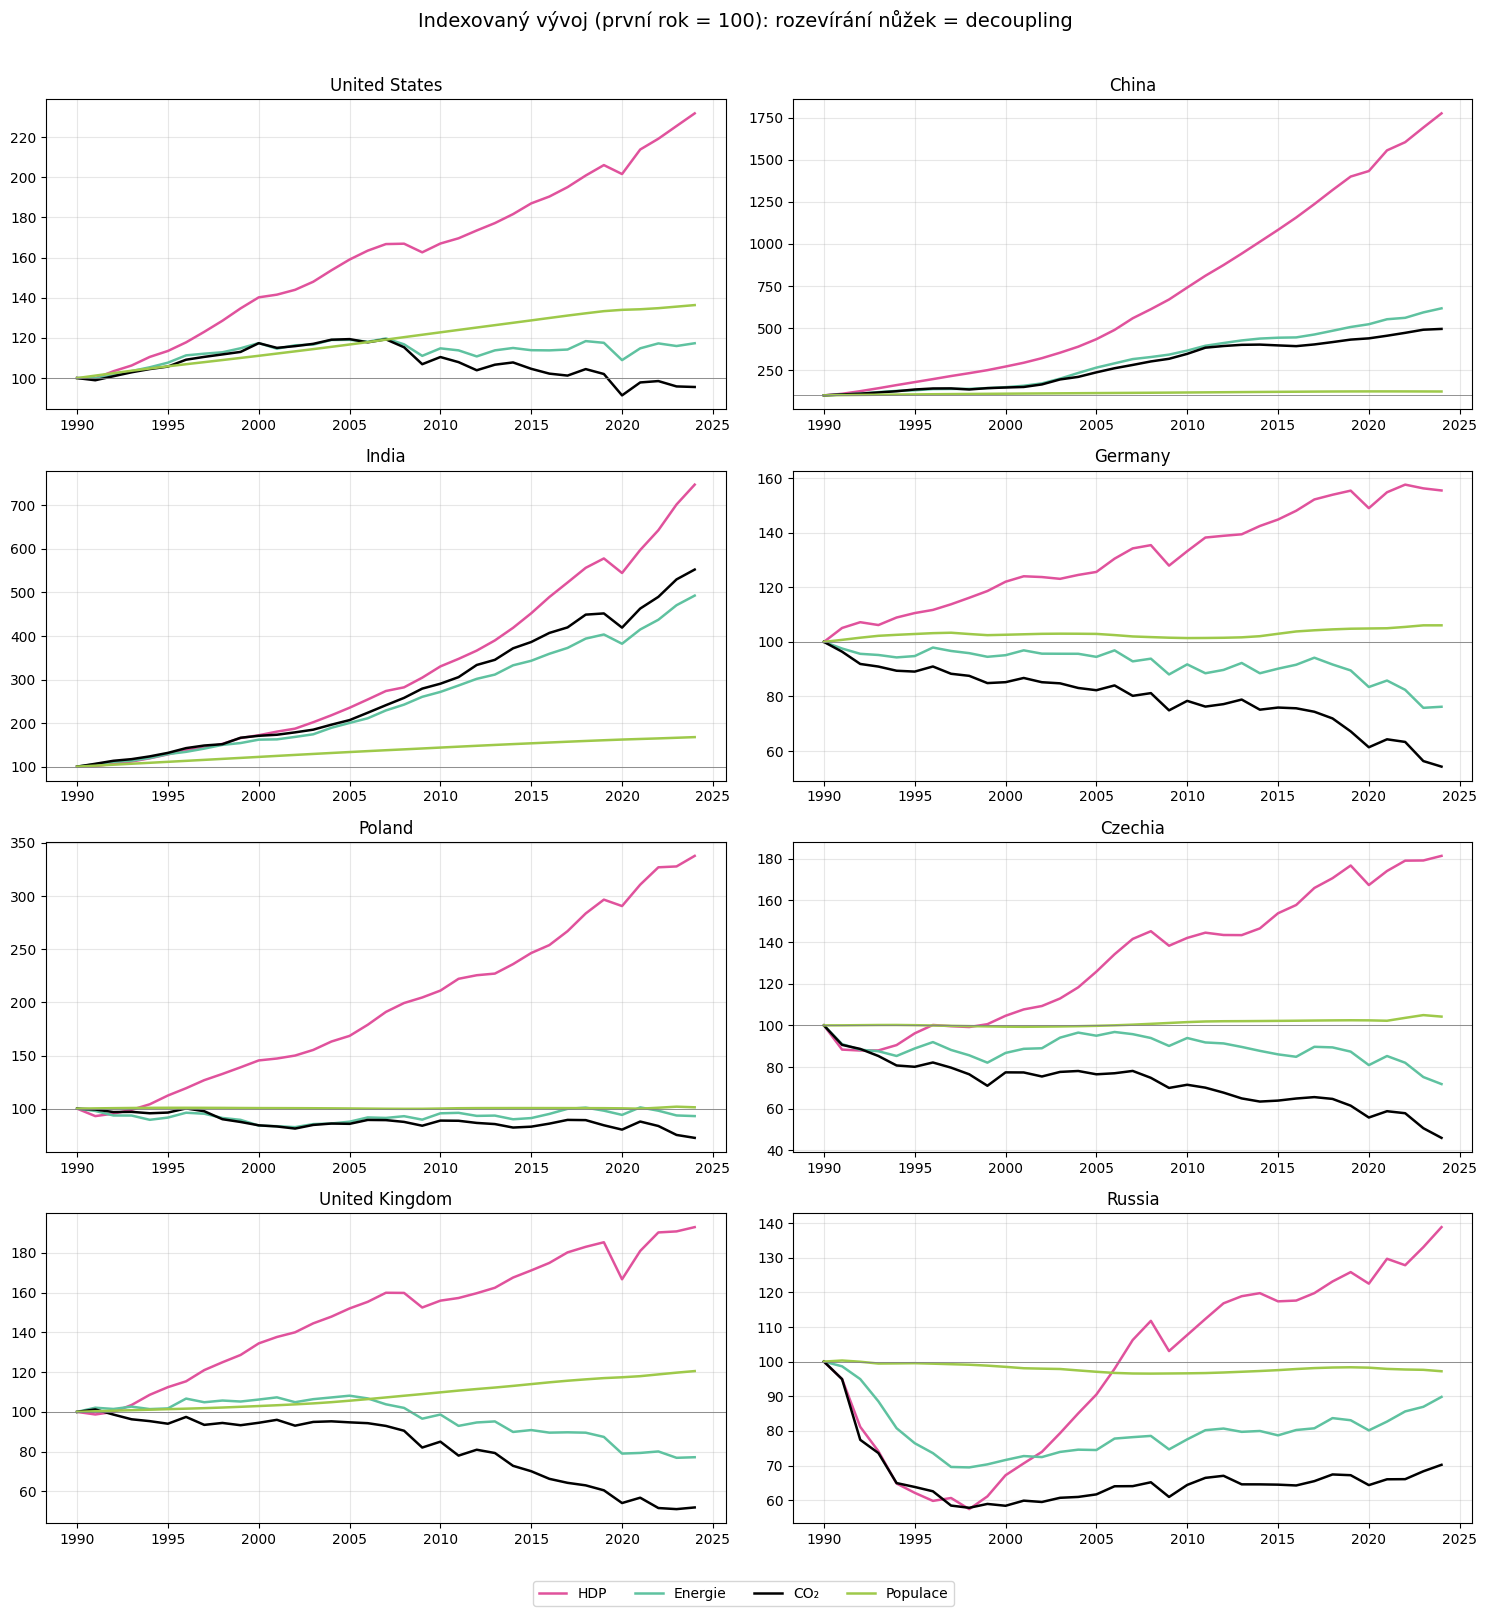

In [ ]:
def vykresli_index(d, zeme, ax=None):
    """HDP, energie, CO2 a populace přepočtené na index 100 v prvním roce."""
    g = d.dropna(subset=["co2", "gdp", "primary_energy_consumption", "population"]).copy()
    b = g.iloc[0]
    if ax is None:
        _, ax = plt.subplots()
    for col, lbl, barva in [("gdp",                         "HDP",      "#e0529c"),
                            ("primary_energy_consumption",  "Energie",  "#5fc2a0"),
                            ("co2",                         "CO₂",      "black"),
                            ("population",                  "Populace", "#9ec94a")]:
        ax.plot(g["year"], 100 * g[col] / b[col], label=lbl, color=barva, lw=1.8)
    ax.axhline(100, color="gray", lw=0.6)
    ax.set_title(zeme)
    ax.grid(alpha=0.3)
    return ax

fig_idx, axes = plt.subplots(radku, sloupcu, figsize=(15, 4 * radku))
axes = np.array(axes).flatten()
for i, zeme in enumerate(zeme_k):
    vykresli_index(vysledky[zeme], zeme, ax=axes[i])
for j in range(n, len(axes)):
    axes[j].set_visible(False)
ruk, pop = axes[0].get_legend_handles_labels()
fig_idx.legend(ruk, pop, loc="lower center", ncol=4, fontsize=10)
fig_idx.suptitle("Indexovaný vývoj (první rok = 100), decoupling", fontsize=14, y=1.0)
fig_idx.tight_layout(rect=[0, 0.03, 1, 0.99])
fig_idx.savefig("kaya_index.png", dpi=150, bbox_inches="tight")
plt.show()

Trajektorie: CO₂ na osobu vs HDP na osobu

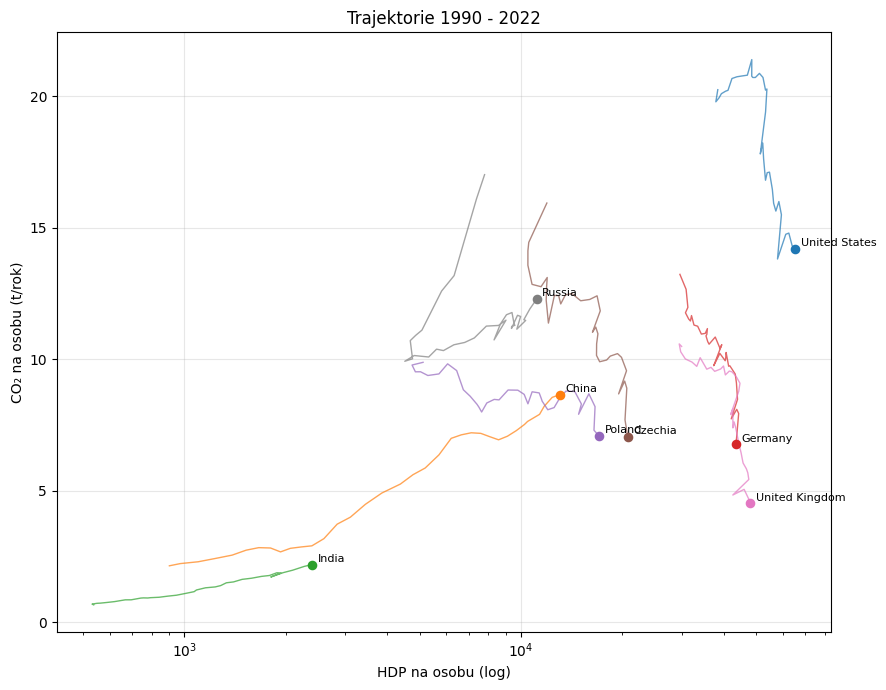

In [47]:
fig_dec, ax = plt.subplots(figsize=(9, 7))
for zeme in zeme_k:
    g = vysledky[zeme].dropna(subset=["gdp_pc", "co2_per_capita"]).copy()
    ax.plot(g["gdp_pc"], g["co2_per_capita"], lw=1, alpha=0.7)
    ax.scatter(g["gdp_pc"].iloc[-1], g["co2_per_capita"].iloc[-1], s=35, zorder=5)
    ax.annotate(zeme, (g["gdp_pc"].iloc[-1], g["co2_per_capita"].iloc[-1]),
                fontsize=8, xytext=(4, 2), textcoords="offset points")
ax.set_xscale("log")
ax.set_xlabel("HDP na osobu (log)")
ax.set_ylabel("CO₂ na osobu (t/rok)")
ax.set_title("Trajektorie 1990 - 2022")
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

 Společné šoky: tepelotní mapa meziročního růstu emisí

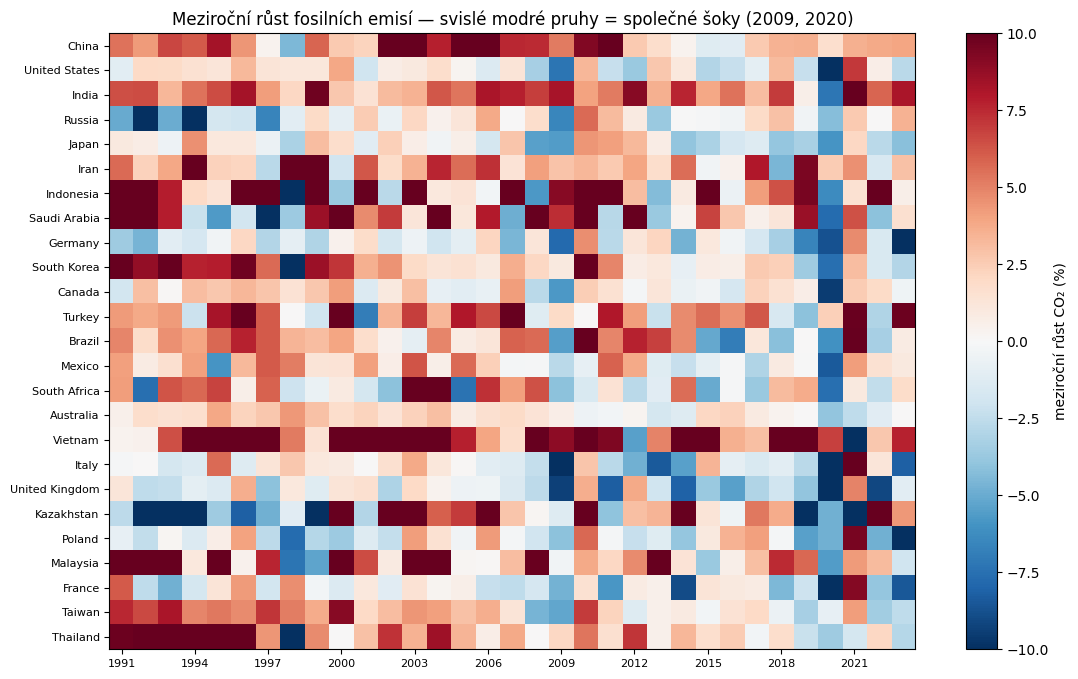

In [48]:
# 25 největších emitentů (2023)
top = (df[(df["year"] == 2023) & df["iso_code"].notna() & (df["iso_code"].str.len() == 3)]
       .dropna(subset=["co2"]).nlargest(25, "co2")["country"].tolist())

H = (df[df["country"].isin(top) & df["year"].between(1990, 2023)]
     .pivot_table(index="country", columns="year", values="co2"))
H = H.reindex(top)                       # pořadí podle velikosti emisí
Hg = (H.pct_change(axis=1) * 100).iloc[:, 1:]   # meziroční růst %, bez prvního (NaN) sloupce

fig_heat, ax = plt.subplots(figsize=(13, 8))
im = ax.imshow(Hg.values, aspect="auto", cmap="RdBu_r", vmin=-10, vmax=10)
ax.set_yticks(range(len(Hg.index)))
ax.set_yticklabels(Hg.index, fontsize=8)
ax.set_xticks(range(0, Hg.shape[1], 3))
ax.set_xticklabels(Hg.columns[::3], fontsize=8)
fig_heat.colorbar(im, label="meziroční růst CO₂ (%)")
ax.set_title("Meziroční růst fosilních emisí — svislé modré pruhy = společné šoky (2009, 2020)")
fig_heat.savefig("kaya_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()

Žebříček: kdo nejvíc dekarbonizoval energetický mix

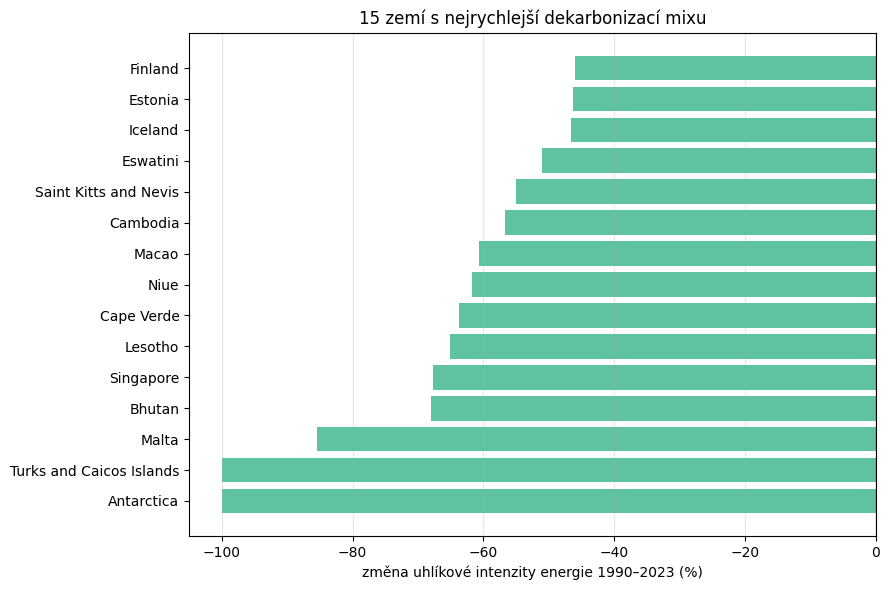

In [49]:
top_dek = piv.nsmallest(15, "zmena_pct").sort_values("zmena_pct", ascending=True)
fig_rank, ax = plt.subplots(figsize=(9, 6))
ax.barh(top_dek["country"], top_dek["zmena_pct"], color="#5fc2a0")
ax.axvline(0, color="black", lw=0.8)
ax.set_xlabel(f"změna uhlíkové intenzity energie {rok_zac}–{rok_kon} (%)")
ax.set_title("15 zemí s nejrychlejší dekarbonizací mixu")
ax.grid(axis="x", alpha=0.3)
fig_rank.tight_layout()
fig_rank.savefig("kaya_zebricek.png", dpi=150, bbox_inches="tight")
plt.show()




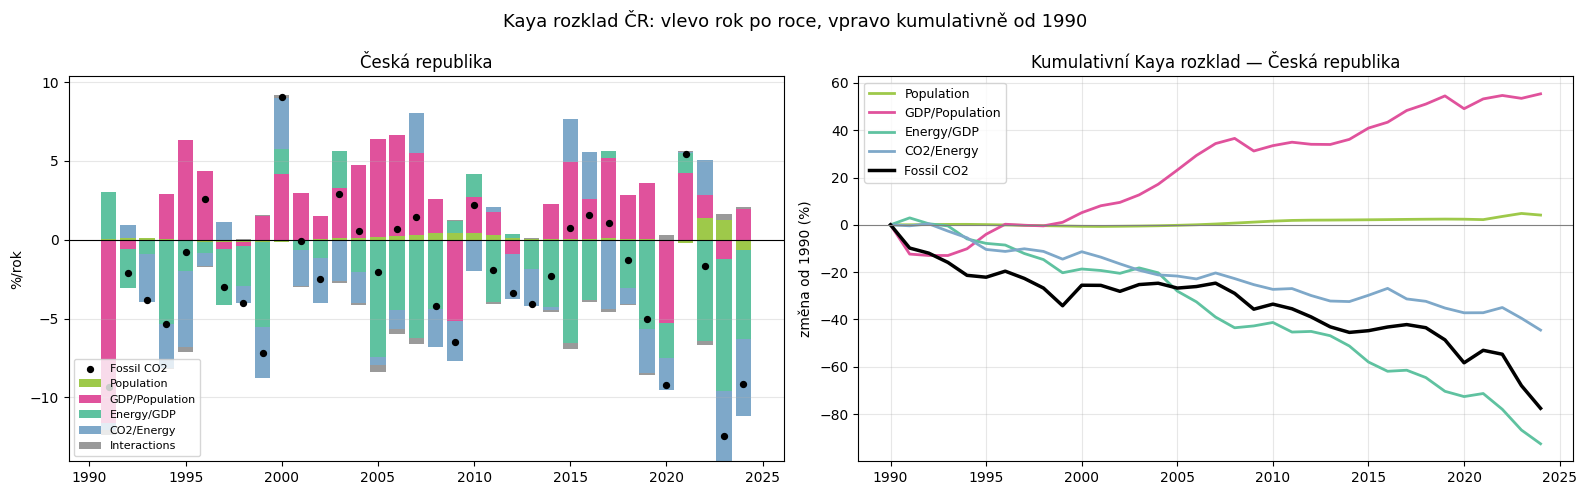

In [50]:
d_cz = vysledky["Czechia"]

fig_cz, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5))
vykresli_kaya(d_cz, "Česká republika", ax=ax1)
ax1.set_ylabel("%/rok")
ax1.legend(loc="lower left", fontsize=8)
vykresli_kaya_kumulativ(d_cz, "Česká republika", ax=ax2)
fig_cz.suptitle("Kaya rozklad ČR: vlevo rok po roce, vpravo kumulativně od 1990", fontsize=13)
fig_cz.tight_layout()
fig_cz.savefig("cz_rozklad.png", dpi=150, bbox_inches="tight")
plt.show()


ČR mezi středoevropskými sousedy (CO₂, index 1990 = 100)

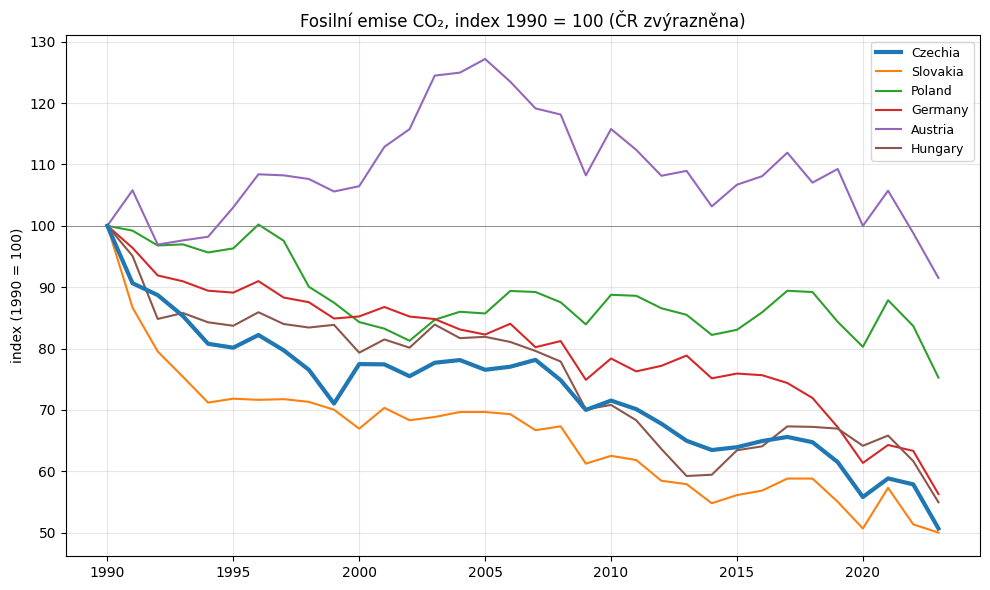

In [51]:
# emise bereme přímo z OWID (rychlé, nezávislé na World Bank)
srovnani = ["Czechia", "Slovakia", "Poland", "Germany", "Austria", "Hungary"]

fig_cmp, ax = plt.subplots(figsize=(10, 6))
for zeme in srovnani:
    g = (df[(df["country"] == zeme) & df["year"].between(1990, 2023)]
         .dropna(subset=["co2"]).sort_values("year"))
    if g.empty:
        continue
    zaklad = g["co2"].iloc[0]
    ax.plot(g["year"], 100 * g["co2"] / zaklad, label=zeme,
            linewidth=3 if zeme == "Czechia" else 1.5,
            zorder=5 if zeme == "Czechia" else 2)
ax.axhline(100, color="gray", lw=0.6)
ax.set_title("Fosilní emise CO₂, index 1990 = 100 (ČR zvýrazněna)")
ax.set_ylabel("index (1990 = 100)")
ax.legend(fontsize=9)
ax.grid(alpha=0.3)
fig_cmp.tight_layout()
fig_cmp.savefig("cz_sousede.png", dpi=150, bbox_inches="tight")
plt.show()

Emise na osobu: kde ČR stojí ku EU a světu

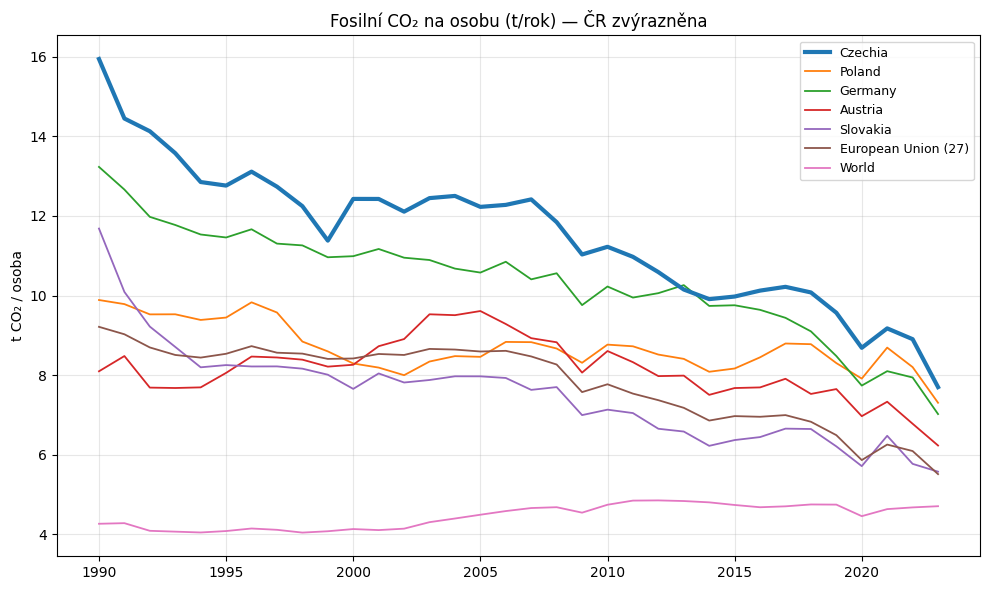

In [52]:
srovnani_pc = ["Czechia", "Poland", "Germany", "Austria", "Slovakia",
               "European Union (27)", "World"]

fig_pc, ax = plt.subplots(figsize=(10, 6))
for zeme in srovnani_pc:
    g = (df[(df["country"] == zeme) & df["year"].between(1990, 2023)]
         .dropna(subset=["co2_per_capita"]).sort_values("year"))
    if g.empty:
        print("  ! v datech není:", zeme)
        continue
    ax.plot(g["year"], g["co2_per_capita"], label=zeme,
            linewidth=3 if zeme == "Czechia" else 1.3,
            zorder=5 if zeme == "Czechia" else 2)
ax.set_title("Fosilní CO₂ na osobu (t/rok) — ČR zvýrazněna")
ax.set_ylabel("t CO₂ / osoba")
ax.legend(fontsize=9)
ax.grid(alpha=0.3)
fig_pc.tight_layout()
fig_pc.savefig("cz_per_capita.png", dpi=150, bbox_inches="tight")
plt.show()

ulozeni dat


In [53]:
vse = pd.concat([d.assign(zeme=z) for z, d in vysledky.items()], ignore_index=True)
sloupce_ven = ["zeme", "year", "co2", "population", "gdp", "primary_energy_consumption",
               "gdp_pc", "en_int", "co2_int",
               "population_g", "gdp_pc_g", "en_int_g", "co2_int_g", "interactions", "co2_g"]
vse[sloupce_ven].to_csv("kaya_data.csv", index=False)
print("Uloženo:", vse["zeme"].nunique(), "zemí,", len(vse), "řádků")

Uloženo: 8 zemí, 280 řádků
